In [325]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pickle

In [326]:
df=pd.read_csv("Preprocessed_Demand_forecasting.csv")
df

,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discount_price,Sell through rate
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [327]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [328]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discount_price,Sell through rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [329]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday',
       'Discount_price', 'Sell through rate'],
      dtype='object')

In [330]:
features=['Price',
         'Discount',
         'Inventory Level',
         'Promotion',
         'Competitor Pricing',
         'Category']

In [331]:
X=df[features].copy()

In [332]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [333]:
targat='Demand'
y=df[targat]

In [334]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [335]:

categorical_cols=X.select_dtypes(include='object').columns
categorical_cols

Index(['Category'], dtype='object')

In [336]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


In [337]:
label_encoders

{'Category': LabelEncoder()}

In [338]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [339]:
X_train

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
64570,48.58,20,349,1,53.14,0
45185,60.72,10,308,1,52.42,3
72380,13.17,15,122,1,13.05,3
15663,48.93,10,512,0,58.36,3
33203,99.02,10,149,0,96.18,1
...,...,...,...,...,...,...
21875,106.81,10,38,0,94.92,2
12355,81.23,15,215,1,98.11,1
59635,96.51,0,307,0,90.70,0
75689,48.67,25,394,1,44.88,3


In [340]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1    
)

In [341]:
param_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [342]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dict,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1    
)

In [ ]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
best_xgb_model = random_search.best_estimator_

print(type(best_xgb_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [ ]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [ ]:
best_model=random_search.best_estimator_

In [ ]:
y_pred=best_model.predict(X_test)

In [ ]:
y_pred

array([120.80639 , 106.69259 , 101.28342 , ...,  76.996544, 175.04279 ,
       107.95786 ], dtype=float32)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


MSE: 1271.568115234375
RMSE: 35.65905376246508


In [ ]:
best_model.feature_importances_

array([0.07514238, 0.0209516 , 0.02020666, 0.5804649 , 0.02388594,
       0.2793485 ], dtype=float32)

In [ ]:
feature_importances=pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [ ]:
feature_importances

Promotion             0.580465
Category              0.279348
Price                 0.075142
Competitor Pricing    0.023886
Discount              0.020952
Inventory Level       0.020207
dtype: float32

<Axes: title={'center': 'Feature Importance'}>

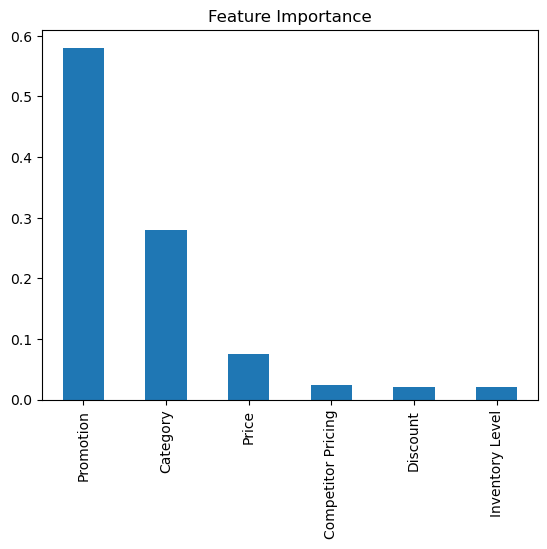

In [ ]:
feature_importances.plot(kind='bar',title="Feature Importance")

In [ ]:
with open('labelencoder.pkl','wb') as f:
    pickle.dump(label_encoders,f)

In [ ]:
with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("XGBoost model saved successfully!")


XGBoost model saved successfully!
